# 7 - Benchmark EoMT - DINOv2-Base + Transformer Decoder

|                |                                                           |
| -------------- | --------------------------------------------------------- |
| **Modèle**     | EoMT simplifié — DINOv2-Base + tête de segmentation dense |
| **Backbone**   | `facebook/dinov2-base` (ViT-Base, ~86M params)            |
| **Framework**  | PyTorch + HuggingFace `transformers`                      |
| **Résolution** | 256 × 256                                                 |


In [2]:
import sys
print(sys.executable)

/home/ui/PROJ9/.env_eomt/bin/python


In [ ]:
import subprocess, sys

def check_pytorch_sm61():
    try:
        import torch
        if not torch.cuda.is_available():
            return False, torch.__version__
        cap = torch.cuda.get_device_capability(0)
        try:
            t = torch.zeros(2, device="cuda")
            _ = t + 1
            return True, torch.__version__
        except Exception:
            return False, torch.__version__
    except ImportError:
        return False, "absent"

ok, ver = check_pytorch_sm61()
print(f"PyTorch actuel : {ver}  |  GPU OK : {ok}")

if not ok:
    print()
    print("PyTorch incompatible avec sm_61")
    print("Installation de torch 2.0.1+cu117 (dernière version supportant sm_61)")
    print()
    cmd = [
        sys.executable, "-m", "pip", "install",
        "torch==2.0.1+cu117",
        "torchvision==0.15.2+cu117",
        "--index-url", "https://download.pytorch.org/whl/cu117",
        "--quiet"
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print("Installation réussie.")
        print("Restart Kernel requis")
    else:
        print("Erreur installation :")
        print(result.stderr[-2000:])
        print()
        print("Commande manuelle :")
        print("pip install torch==2.0.1+cu117 torchvision==0.15.2+cu117 --index-url https://download.pytorch.org/whl/cu117")
else:
    print(f"OK")


PyTorch actuel : 2.0.1+cu117  |  GPU OK : True
GPU opérationnel sur sm_61.


In [4]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")


ROOT = /home/ui/PROJ9


In [ ]:
import os, gc, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoConfig
from PIL import Image as PILImage
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

from scripts.config import ensure_dirs, resolve_split_csv, CITYSCAPES_DIR, EXP_DIR
from scripts.preprocessing import (
    load_rgb, load_mask_labelids, remap_to_groups, colorize_groups,
    CATEGORY_NAMES, IGNORE_LABEL, N_CLASSES, PALETTE
)
from scripts.augmentations import make_train_aug

ensure_dirs()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")

if DEVICE == "cuda":
    cap = torch.cuda.get_device_capability(0)
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"CC       : sm_{cap[0]}{cap[1]}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    try:
        _t = torch.zeros(2, device="cuda"); _ = _t + 1
        print("GPU operationnel.")
    except Exception as e:
        print(f"GPU inutilisable : {e}")
        print("Bascule sur CPU")
        DEVICE = "cpu"

USE_AMP = (DEVICE == "cuda" and torch.cuda.get_device_capability(0)[0] >= 7)
print(f"AMP (mixed precision) : {USE_AMP}")


PyTorch  : 2.0.1+cu117
Device   : cuda
GPU      : NVIDIA GeForce GTX 1080 Ti
CC       : sm_61
VRAM     : 11.8 GB
GPU operationnel.
AMP (mixed precision) : False


## Configuration


In [ ]:
SIZE_HW        = (256, 256)
BATCH          = 4
EPOCHS         = 50
PATIENCE       = 10
LR             = 5e-4
EPOCHS_FT      = 30
LR_FT          = 5e-5
PATIENCE_FT    = 10
SEED           = 42
AUG            = True
GRAD_ACCUM     = 2 if USE_AMP else 1
DINOV2_MODEL   = "facebook/dinov2-base"

OUT_DIR = EXP_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"EOMT_DINOV2BASE_{SIZE_HW[0]}x{SIZE_HW[1]}"
    f"_b{BATCH}xa{GRAD_ACCUM}_aug{int(AUG)}_e{EPOCHS}ft{EPOCHS_FT}_seed{SEED}"
)
BEST_PATH    = OUT_DIR / f"{RUN_NAME}.pt"
RESULTS_JSON = OUT_DIR / f"{RUN_NAME}_results.json"

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
print("Run :", RUN_NAME)
print(f"Grad accum : {GRAD_ACCUM}  (batch effectif : {BATCH * GRAD_ACCUM})")


Run : EOMT_DINOV2BASE_256x256_b4xa1_aug1_e50ft30_seed42
Grad accum : 1  (batch effectif : 4)


## Dataset PyTorch


In [7]:
class CityscapesDatasetPT(Dataset):
    MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, df, base_dir, size_hw=(256,256), augment=None):
        self.df       = df.reset_index(drop=True)
        self.base_dir = str(base_dir)
        self.H, self.W = size_hw
        self.augment  = augment

    def _resolve(self, row, col_abs, col_rel):
        if col_abs in row and isinstance(row[col_abs], str) and row[col_abs]:
            return row[col_abs]
        return f"{self.base_dir}/{row[col_rel]}"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = load_rgb(self._resolve(row, "image_path", "image_rel"))
        msk    = remap_to_groups(load_mask_labelids(self._resolve(row, "mask_path", "mask_rel")))
        img    = img.resize((self.W, self.H), PILImage.BILINEAR)
        msk    = msk.resize((self.W, self.H), PILImage.NEAREST)
        img_np = np.array(img, dtype=np.float32) / 255.0
        msk_np = np.array(msk, dtype=np.int64)

        if self.augment is not None:
            np.random.seed(idx * 7919 % (2**31))
            out    = self.augment(image=(img_np*255).astype(np.uint8), mask=msk_np.astype(np.uint8))
            img_np = out["image"].astype(np.float32) / 255.0
            msk_np = out["mask"].astype(np.int64)

        img_np = (img_np - self.MEAN) / self.STD
        return torch.from_numpy(img_np.transpose(2,0,1)), torch.from_numpy(msk_np)


df       = pd.read_csv(resolve_split_csv())
train_df = df[df["split_final"] == "train"].copy()
val_df   = df[df["split_final"] == "val"].copy()
test_df  = df[df["split_final"] == "test"].copy()
print(f"Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")

train_aug    = make_train_aug() if AUG else None
train_ds     = CityscapesDatasetPT(train_df, CITYSCAPES_DIR, SIZE_HW, augment=train_aug)
val_ds       = CityscapesDatasetPT(val_df,   CITYSCAPES_DIR, SIZE_HW)
test_ds      = CityscapesDatasetPT(test_df,  CITYSCAPES_DIR, SIZE_HW)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=(DEVICE=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=(DEVICE=="cuda"))
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=(DEVICE=="cuda"))
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")


Train : 2380  |  Val : 500  |  Test : 595
Batches — train: 595 | val: 125 | test: 149


/home/ui/PROJ9/scripts/augmentations.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/home/ui/PROJ9/.env_eomt/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
import sys
print(sys.executable)

import torch
print("torch OK :", torch.__version__)

import transformers
print("transformers OK :", transformers.__version__)

import transformers.utils.import_utils as iu
print("torch disponible selon transformers :", iu.is_torch_available())

/home/ui/PROJ9/.env_eomt/bin/python
torch OK : 2.0.1+cu117
transformers OK : 4.44.2
torch disponible selon transformers : True


## Architecture EoMT


In [ ]:
class EoMTSegHead(nn.Module):
    def __init__(self, embed_dim=768, n_classes=8, img_hw=(256,256), patch_size=14):
        super().__init__()
        self.H, self.W = img_hw
        self.ph = img_hw[0] // patch_size
        self.pw = img_hw[1] // patch_size
        self.n_spatial = self.ph * self.pw

        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.head = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, n_classes, 1),
        )

    def forward(self, tokens):
        B, N, C = tokens.shape
        spatial = tokens[:, N - self.n_spatial:, :]
        x = spatial.reshape(B, self.ph, self.pw, C).permute(0, 3, 1, 2)
        x = self.up1(x)
        x = self.up2(x)
        x = F.interpolate(x, size=(self.H, self.W), mode="bilinear", align_corners=False)
        return self.head(x)


class EoMTModel(nn.Module):
    def __init__(self, dinov2_name=DINOV2_MODEL, n_classes=N_CLASSES,
                 img_hw=SIZE_HW, trainable_encoder=False):
        super().__init__()
        cfg        = AutoConfig.from_pretrained(dinov2_name)
        patch_size = getattr(cfg, "patch_size", 14)
        embed_dim  = cfg.hidden_size
        print(f"DINOv2 : embed_dim={embed_dim}, patch_size={patch_size}")

        self.backbone = AutoModel.from_pretrained(dinov2_name)
        self.head     = EoMTSegHead(embed_dim, n_classes, img_hw, patch_size)
        self.set_encoder_trainable(trainable_encoder)

    def set_encoder_trainable(self, v: bool):
        for p in self.backbone.parameters():
            p.requires_grad = bool(v)

    def forward(self, x):
        out = self.backbone(pixel_values=x.float(), output_hidden_states=False)
        return self.head(out.last_hidden_state)


model_pt = EoMTModel(trainable_encoder=False).to(DEVICE)
n_total  = sum(p.numel() for p in model_pt.parameters())
n_train  = sum(p.numel() for p in model_pt.parameters() if p.requires_grad)
print(f"Params totaux       : {n_total:,}")
print(f"Params entraînables : {n_train:,}  (phase 1 — tête seulement)")

with torch.no_grad():
    dummy = torch.zeros(1, 3, *SIZE_HW).to(DEVICE)
    out   = model_pt(dummy)
    print(f"Forward OK — sortie : {out.shape}")
del dummy, out


DINOv2 : embed_dim=768, patch_size=14
Params totaux       : 87,573,576
Params entraînables : 993,096  (phase 1 — tête seulement)
Forward OK — sortie : torch.Size([1, 8, 256, 256])


## Loss et métriques


In [10]:
def ce_dice_loss(logits, targets, n_classes=N_CLASSES, ignore=IGNORE_LABEL, dice_w=0.5):
    ce    = F.cross_entropy(logits.float(), targets, ignore_index=ignore)
    valid = (targets != ignore)
    t_s   = targets.clone(); t_s[~valid] = 0
    probs = F.softmax(logits.float(), dim=1)
    t_oh  = F.one_hot(t_s, n_classes).permute(0,3,1,2).float()
    vf    = valid.unsqueeze(1).float()
    
    t_oh_masked  = t_oh * vf
    probs_masked = probs * vf
    
    inter = (t_oh_masked * probs_masked).sum(dim=(0,2,3))
    denom = (t_oh_masked + probs_masked).sum(dim=(0,2,3)) + 1e-6
    dice  = 1.0 - (2.0 * inter / denom).mean()
    return ce + dice_w * dice


def batch_miou(preds_argmax, targets, n_classes=N_CLASSES, ignore=IGNORE_LABEL):
    p = preds_argmax.cpu().numpy().flatten()
    t = targets.cpu().numpy().flatten()
    valid = t != ignore
    p, t  = p[valid], t[valid]
    iou = []
    for c in range(n_classes):
        tp = ((p==c)&(t==c)).sum(); fp = ((p==c)&(t!=c)).sum(); fn = ((p!=c)&(t==c)).sum()
        d  = tp+fp+fn
        iou.append(float(tp)/float(d) if d > 0 else 0.0)
    return float(np.mean(iou))


## Boucle d'entraînement :


In [11]:
def run_epoch(model, loader, optimizer=None, phase="train", grad_accum=1):
    is_train = (phase == "train")
    model.train(is_train)
    total_loss, total_miou, n = 0.0, 0.0, 0
    if is_train and optimizer:
        optimizer.zero_grad()

    for step, (X, y) in enumerate(loader):
        X, y = X.to(DEVICE), y.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(X)
            loss   = ce_dice_loss(logits, y) / grad_accum

        if is_train and optimizer:
            loss.backward()
            if (step + 1) % grad_accum == 0:
                optimizer.step()
                optimizer.zero_grad()

        with torch.no_grad():
            miou = batch_miou(logits.detach().argmax(dim=1), y)

        total_loss += loss.item() * grad_accum
        total_miou += miou
        n          += 1

        if n % 100 == 0:
            print(f"  [{n}/{len(loader)}] loss={total_loss/n:.4f}  mIoU={total_miou/n:.4f}", end="\r")

    return total_loss / n, total_miou / n


## Phase 1 - Encodeur gelé


In [12]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_pt.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=4, min_lr=1e-6, verbose=True
)

history   = {"loss": [], "val_loss": [], "mIoU": [], "val_mIoU": []}
best_miou = -1.0
no_imp    = 0
t0        = time.time()

for epoch in range(1, EPOCHS+1):
    t_ep       = time.time()
    tr_l, tr_m = run_epoch(model_pt, train_loader, optimizer, "train", GRAD_ACCUM)
    va_l, va_m = run_epoch(model_pt, val_loader,   None,      "val",   1)
    scheduler.step(va_m)
    history["loss"].append(tr_l);    history["val_loss"].append(va_l)
    history["mIoU"].append(tr_m);    history["val_mIoU"].append(va_m)

    elapsed = time.time() - t_ep
    print(f"Ep {epoch:3d}/{EPOCHS}  loss={tr_l:.4f} mIoU={tr_m:.4f} | "
          f"val_loss={va_l:.4f} val_mIoU={va_m:.4f}  [{elapsed:.0f}s]")

    if va_m > best_miou:
        best_miou = va_m; no_imp = 0
        torch.save({"model": model_pt.state_dict(), "epoch": epoch,
                    "val_mIoU": va_m, "history": dict(history)}, BEST_PATH)
        print(f"  -> Checkpoint sauvegarde (val_mIoU={va_m:.4f})")
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f"  EarlyStopping ep {epoch}"); break

t_ph1    = time.time() - t0
ep_split = len(history["loss"])
hist_ph1 = {k: list(v) for k, v in history.items()}
print(f"\nPhase 1 : {t_ph1/60:.1f} min  |  Meilleur val mIoU : {best_miou:.4f}")


Ep   1/50  loss=0.7550 mIoU=0.5431 | val_loss=0.5587 val_mIoU=0.5934  [118s]
  -> Checkpoint sauvegarde (val_mIoU=0.5934)
Ep   2/50  loss=0.5993 mIoU=0.5894 | val_loss=0.5230 val_mIoU=0.6042  [115s]
  -> Checkpoint sauvegarde (val_mIoU=0.6042)
Ep   3/50  loss=0.5744 mIoU=0.5970 | val_loss=0.5110 val_mIoU=0.6091  [117s]
  -> Checkpoint sauvegarde (val_mIoU=0.6091)
Ep   4/50  loss=0.5554 mIoU=0.6053 | val_loss=0.5040 val_mIoU=0.6119  [114s]
  -> Checkpoint sauvegarde (val_mIoU=0.6119)
Ep   5/50  loss=0.5467 mIoU=0.6074 | val_loss=0.4951 val_mIoU=0.6135  [117s]
  -> Checkpoint sauvegarde (val_mIoU=0.6135)
Ep   6/50  loss=0.5388 mIoU=0.6116 | val_loss=0.4886 val_mIoU=0.6197  [115s]
  -> Checkpoint sauvegarde (val_mIoU=0.6197)
Ep   7/50  loss=0.5340 mIoU=0.6120 | val_loss=0.4865 val_mIoU=0.6178  [113s]
Ep   8/50  loss=0.5290 mIoU=0.6163 | val_loss=0.4804 val_mIoU=0.6218  [114s]
  -> Checkpoint sauvegarde (val_mIoU=0.6218)
Ep   9/50  loss=0.5230 mIoU=0.6170 | val_loss=0.4752 val_mIoU=0.6235 

## Phase 2 - Fine-tuning complet (DINOv2 dégelé)


In [ ]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model_pt.load_state_dict(ckpt["model"])
model_pt.set_encoder_trainable(True)

optimizer_ft = torch.optim.AdamW([
    {"params": model_pt.head.parameters(),     "lr": LR_FT},
    {"params": model_pt.backbone.parameters(), "lr": LR_FT * 0.1},
], weight_decay=1e-4)
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode="max", factor=0.5, patience=4, min_lr=1e-7, verbose=True
)

no_imp_ft = 0
t0_ft     = time.time()

for epoch in range(1, EPOCHS_FT+1):
    t_ep       = time.time()
    tr_l, tr_m = run_epoch(model_pt, train_loader, optimizer_ft, "train", GRAD_ACCUM)
    va_l, va_m = run_epoch(model_pt, val_loader,   None,         "val",   1)
    scheduler_ft.step(va_m)
    history["loss"].append(tr_l);    history["val_loss"].append(va_l)
    history["mIoU"].append(tr_m);    history["val_mIoU"].append(va_m)

    elapsed = time.time() - t_ep
    print(f"FT {epoch:3d}/{EPOCHS_FT}  loss={tr_l:.4f} mIoU={tr_m:.4f} | "
          f"val_loss={va_l:.4f} val_mIoU={va_m:.4f}  [{elapsed:.0f}s]")

    if va_m > best_miou:
        best_miou = va_m; no_imp_ft = 0
        torch.save({"model": model_pt.state_dict(), "epoch": EPOCHS+epoch,
                    "val_mIoU": va_m, "history": dict(history)}, BEST_PATH)
        print(f"  -> Meilleur checkpoint FT (val_mIoU={va_m:.4f})")
    else:
        no_imp_ft += 1
        if no_imp_ft >= PATIENCE_FT:
            print(f"  EarlyStopping FT ep {epoch}"); break

t_ph2  = time.time() - t0_ft
t_tot  = t_ph1 + t_ph2
print(f"\nPhase 2 : {t_ph2/60:.1f} min  |  Total : {t_tot/60:.1f} min")


FT   1/30  loss=0.4401 mIoU=0.6601 | val_loss=0.3887 val_mIoU=0.6732  [181s]
  -> Meilleur checkpoint FT (val_mIoU=0.6732)
FT   2/30  loss=0.4046 mIoU=0.6805 | val_loss=0.3735 val_mIoU=0.6854  [182s]
  -> Meilleur checkpoint FT (val_mIoU=0.6854)
FT   3/30  loss=0.3981 mIoU=0.6855 | val_loss=0.3685 val_mIoU=0.6896  [182s]
  -> Meilleur checkpoint FT (val_mIoU=0.6896)
FT   4/30  loss=0.3810 mIoU=0.6953 | val_loss=0.3561 val_mIoU=0.6966  [185s]
  -> Meilleur checkpoint FT (val_mIoU=0.6966)
FT   5/30  loss=0.3689 mIoU=0.7031 | val_loss=0.3511 val_mIoU=0.6994  [182s]
  -> Meilleur checkpoint FT (val_mIoU=0.6994)
FT   6/30  loss=0.3606 mIoU=0.7077 | val_loss=0.3479 val_mIoU=0.7029  [182s]
  -> Meilleur checkpoint FT (val_mIoU=0.7029)
FT   7/30  loss=0.3574 mIoU=0.7118 | val_loss=0.3445 val_mIoU=0.7053  [181s]
  -> Meilleur checkpoint FT (val_mIoU=0.7053)
FT   8/30  loss=0.3488 mIoU=0.7158 | val_loss=0.3429 val_mIoU=0.7085  [181s]
  -> Meilleur checkpoint FT (val_mIoU=0.7085)
FT   9/30  loss=

## Évaluation finale


In [ ]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE)
model_pt.load_state_dict(ckpt["model"])
model_pt.eval()

def evaluate_loader(model, loader):
    tl, tm, n    = 0.0, 0.0, 0
    all_p, all_t = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y   = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss   = ce_dice_loss(logits, y)
            preds  = logits.argmax(dim=1)
            tl    += loss.item(); tm += batch_miou(preds, y); n += 1
            all_p.append(preds.cpu()); all_t.append(y.cpu())
    return tl/n, tm/n, torch.cat(all_p), torch.cat(all_t)

val_loss,  val_miou,  vp, vt  = evaluate_loader(model_pt, val_loader)
test_loss, test_miou, tp_, tt = evaluate_loader(model_pt, test_loader)
print(f"Val  — Loss: {val_loss:.4f}  mIoU: {val_miou:.4f}")
print(f"Test — Loss: {test_loss:.4f}  mIoU: {test_miou:.4f}")


Val  — Loss: 0.3152  mIoU: 0.7332
Test — Loss: 0.2813  mIoU: 0.7678


In [ ]:
def per_class_iou_from_tensors(preds, targets, n_classes=N_CLASSES, ignore=IGNORE_LABEL):
    p = preds.numpy().flatten(); t = targets.numpy().flatten()
    valid = t != ignore
    conf  = sk_confusion_matrix(t[valid], p[valid], labels=list(range(n_classes)))
    iou   = []
    for c in range(n_classes):
        tp = conf[c,c]; fn = conf[c,:].sum()-tp; fp = conf[:,c].sum()-tp
        d  = tp+fn+fp
        iou.append(float(tp)/float(d) if d > 0 else 0.0)
    return iou

per_class_iou = per_class_iou_from_tensors(tp_, tt)
miou_manual   = np.mean(per_class_iou)
print(f"mIoU test = {miou_manual:.4f}\n")
for i, (name, v) in enumerate(zip(CATEGORY_NAMES, per_class_iou)):
    print(f"  {i} {name:<15} {v:.4f}  {'|' * int(v*30)}")


mIoU test = 0.7857

  0 void            0.8371  |||||||||||||||||||||||||
  1 flat            0.9700  |||||||||||||||||||||||||||||
  2 construction    0.8491  |||||||||||||||||||||||||
  3 object          0.3920  |||||||||||
  4 nature          0.8450  |||||||||||||||||||||||||
  5 sky             0.8998  ||||||||||||||||||||||||||
  6 human           0.6268  ||||||||||||||||||
  7 vehicle         0.8657  |||||||||||||||||||||||||


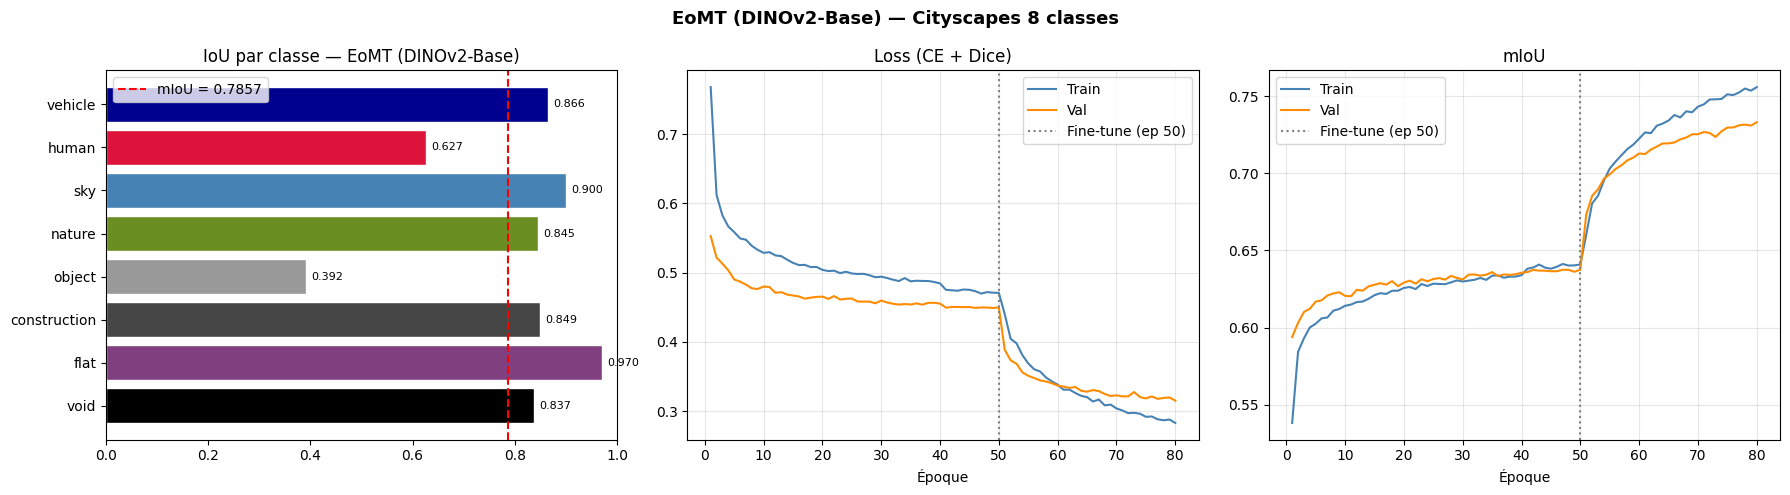

In [ ]:
all_loss  = history["loss"];     all_vloss = history["val_loss"]
all_iou   = history["mIoU"];     all_viou  = history["val_mIoU"]
colors    = [tuple(c/255 for c in PALETTE[i]) for i in range(N_CLASSES)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(CATEGORY_NAMES, per_class_iou, color=colors, edgecolor="white")
axes[0].axvline(miou_manual, color="red", linestyle="--", linewidth=1.5,
                label=f"mIoU = {miou_manual:.4f}")
axes[0].set_xlim(0, 1); axes[0].legend()
axes[0].set_title("IoU par classe — EoMT (DINOv2-Base)")
for i, v in enumerate(per_class_iou):
    axes[0].text(v+0.01, i, f"{v:.3f}", va="center", fontsize=8)

# Loss
axes[1].plot(range(1, len(all_loss)+1), all_loss,  label="Train", color="steelblue")
axes[1].plot(range(1, len(all_vloss)+1), all_vloss, label="Val",  color="darkorange")
axes[1].axvline(ep_split, color="grey", linestyle=":", label=f"Fine-tune (ep {ep_split})")
axes[1].set_xlabel("Époque"); axes[1].set_title("Loss (CE + Dice)")
axes[1].legend(); axes[1].grid(alpha=0.3)

# mIoU
axes[2].plot(range(1, len(all_iou)+1), all_iou,   label="Train", color="steelblue")
axes[2].plot(range(1, len(all_viou)+1), all_viou,  label="Val",  color="darkorange")
axes[2].axvline(ep_split, color="grey", linestyle=":", label=f"Fine-tune (ep {ep_split})")
axes[2].set_xlabel("Époque"); axes[2].set_title("mIoU")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("EoMT (DINOv2-Base) — Cityscapes 8 classes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUT_DIR / f"{RUN_NAME}_summary.png"), dpi=120)
plt.show()


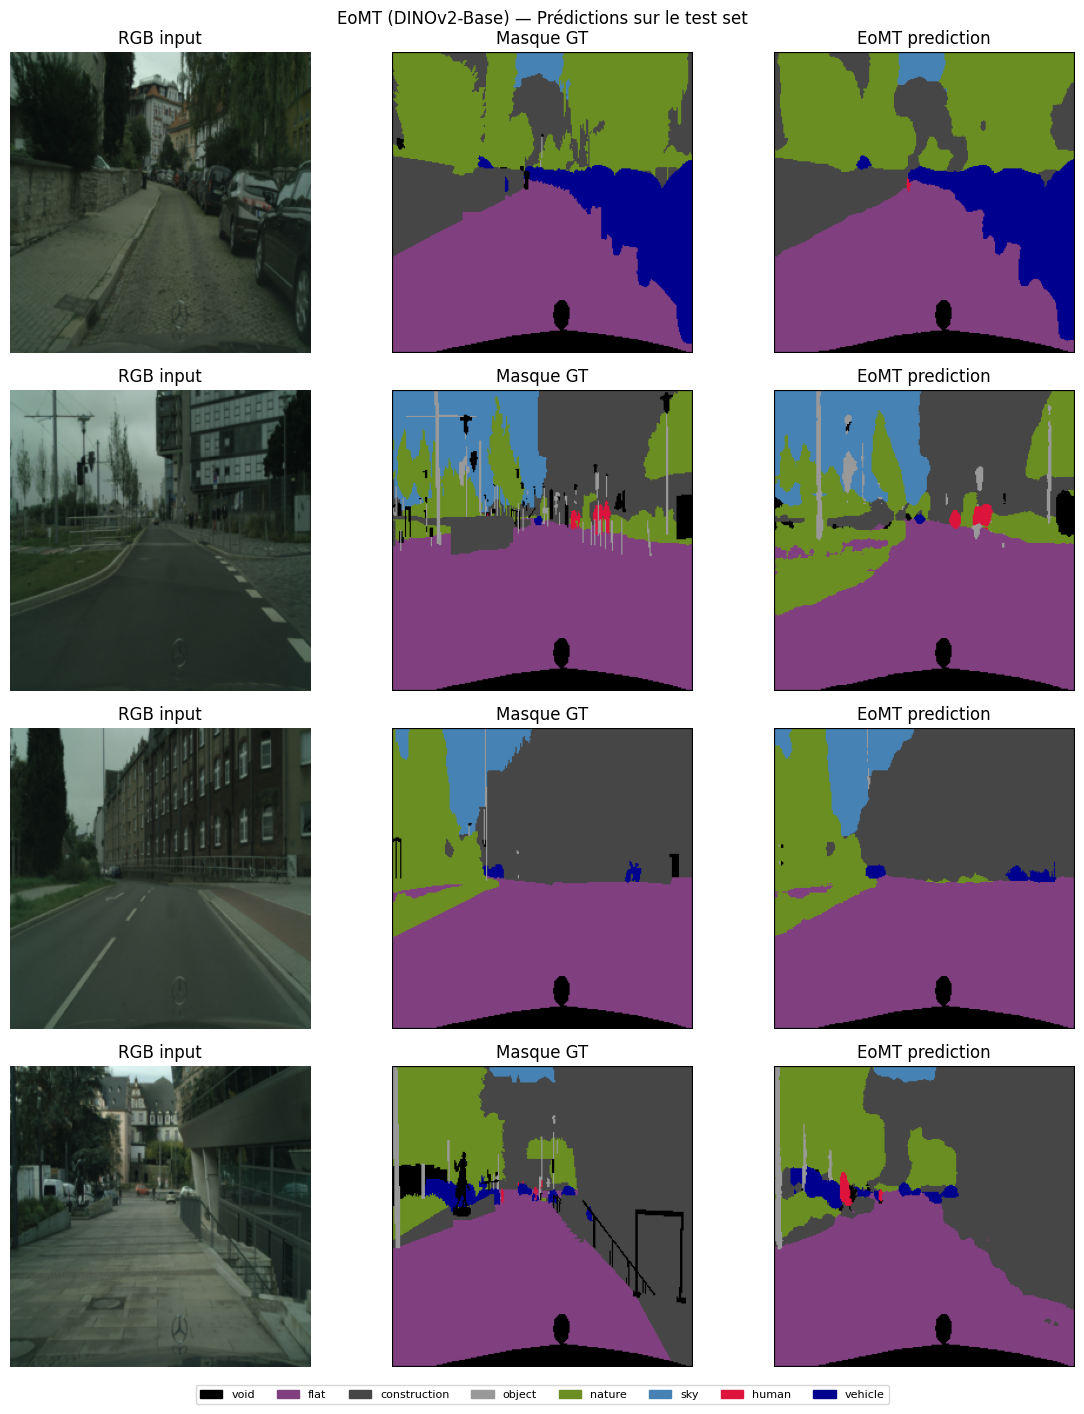

In [ ]:
MEAN_NP = CityscapesDatasetPT.MEAN; STD_NP = CityscapesDatasetPT.STD
model_pt.eval()
X_b, y_b = next(iter(test_loader))
X_s, y_s = X_b[:4].to(DEVICE), y_b[:4]
with torch.no_grad():
    pr = model_pt(X_s).argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 3, figsize=(12, 4*3.5))
for i in range(4):
    arr  = np.clip(X_s[i].cpu().permute(1,2,0).numpy() * STD_NP + MEAN_NP, 0, 1)
    arr  = (arr * 255).astype(np.uint8)
    gt_c = colorize_groups(PILImage.fromarray(y_s[i].numpy().astype(np.uint8)))
    pr_c = colorize_groups(PILImage.fromarray(pr[i].numpy().astype(np.uint8)))
    axes[i,0].imshow(arr);   axes[i,0].set_title("RGB input")
    axes[i,1].imshow(gt_c);  axes[i,1].set_title("Masque GT")
    axes[i,2].imshow(pr_c);  axes[i,2].set_title("EoMT prediction")
    for ax in axes[i]: ax.axis("off")

patches = [mpatches.Patch(color=[c/255 for c in PALETTE[j]], label=CATEGORY_NAMES[j])
           for j in range(N_CLASSES)]
fig.legend(handles=patches, loc="lower center", ncol=N_CLASSES,
           bbox_to_anchor=(0.5, -0.02), fontsize=8)
plt.suptitle("EoMT (DINOv2-Base) — Prédictions sur le test set")
plt.tight_layout()
plt.savefig(str(OUT_DIR / f"{RUN_NAME}_preds.png"), dpi=100, bbox_inches="tight")
plt.show()


## Sauvegarde JSON


In [ ]:
results = {
    "run_name"       : RUN_NAME,
    "model"          : "eomt_dinov2_base",
    "encoder"        : "dinov2_base",
    "framework"      : "pytorch",
    "input_shape"    : list(SIZE_HW) + [3],
    "best_path"      : str(BEST_PATH),
    "train_time_sec" : float(t_tot),
    "epochs_phase1"  : ep_split,
    "epochs_phase2"  : len(history["loss"]) - ep_split,
    "val_loss"       : float(val_loss),
    "val_mIoU"       : float(val_miou),
    "test_loss"      : float(test_loss),
    "test_mIoU"      : float(test_miou),
    "per_class_iou"  : {CATEGORY_NAMES[i]: round(per_class_iou[i], 4) for i in range(N_CLASSES)},
    "history"        : {
        "loss"     : [float(v) for v in history["loss"]],
        "val_loss" : [float(v) for v in history["val_loss"]],
        "mIoU"     : [float(v) for v in history["mIoU"]],
        "val_mIoU" : [float(v) for v in history["val_mIoU"]],
    },
}
with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)

print(f"JSON sauvegarde : {RESULTS_JSON}")
print(f"{'='*50}")
print(f"EoMT DINOv2-Base — Résumé")
print(f"  Val  mIoU : {results['val_mIoU']:.4f}")
print(f"  Test mIoU : {results['test_mIoU']:.4f}")
print(f"  Duree     : {t_tot/60:.1f} min")
print(f"{'='*50}")


JSON sauvegarde : /home/ui/PROJ9/out/experiments/EOMT_DINOV2BASE_256x256_b4xa1_aug1_e50ft30_seed42_results.json
EoMT DINOv2-Base — Résumé
  Val  mIoU : 0.7332
  Test mIoU : 0.7678
  Duree     : 184.6 min
